##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
!pip install -q keras-cv tensorflow matplotlib pillow requests

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

import tensorflow as tf
import keras
import keras_cv

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 17.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 56.3 MB/s eta 0:00:00
TensorFlow: 2.19.0
Keras: 3.10.0
KerasCV: 0.9.0


In [2]:

model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",   
    bounding_box_format="xywh"
)

print("Model loaded successfully.")

Model loaded successfully.


In [6]:
image_urls = [

"https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d",  # person
"https://images.unsplash.com/photo-1517423440428-a5a00ad493e8",  # dog
"https://images.unsplash.com/photo-1503376780353-7e6692767b70",  # car
"https://images.unsplash.com/photo-1544620347-c4fd4a3d5957",     # bus
"https://images.unsplash.com/photo-1507035895480-2b3156c31fc8"   # bicycle

]

def load_image_from_url(url):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return np.array(image)

images = [load_image_from_url(url) for url in image_urls]

print("Number of images:", len(images))
print("Sample image shape:", images[0].shape)

Number of images: 5
Sample image shape: (3582, 2866, 3)


In [7]:
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

In [8]:
def preprocess_image(image):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = inference_resizing(image)
    image = tf.cast(image, tf.uint8)
    return image

In [9]:
def predict_image(model, image):
    resized = preprocess_image(image)
    batch = tf.expand_dims(resized, axis=0)  # shape: (1, 640, 640, 3)
    
    predictions = model.predict(batch, verbose=0)
    return resized, predictions

In [10]:
voc_classes = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

def visualize_predictions(image, predictions):

    image_batch = tf.expand_dims(image, axis=0)

    keras_cv.visualization.plot_bounding_box_gallery(
        image_batch,
        value_range=(0, 255),
        rows=1,
        cols=1,
        y_pred=predictions,
        scale=5,
        font_scale=0.7,
        bounding_box_format="xywh",
        class_mapping={i: name for i, name in enumerate(voc_classes)},
    )

In [11]:
def summarize_predictions(predictions, confidence_threshold=0.3):
    boxes = predictions["boxes"][0]
    classes = predictions["classes"][0]
    confidences = predictions["confidence"][0]

    results = []
    for box, cls_id, score in zip(boxes, classes, confidences):
        if score >= confidence_threshold:
            cls_id = int(cls_id)
            label = voc_classes[cls_id] if 0 <= cls_id < len(voc_classes) else f"class_{cls_id}"
            results.append({
                "label": label,
                "confidence": float(score),
                "box_xywh": box.tolist()
            })
    return results

Image 1
Detected objects:
- person | confidence = 0.964
Image 2
Detected objects:
- dog | confidence = 0.984
Image 3
Detected objects:
- car | confidence = 0.988
Image 4
Detected objects:
- bus | confidence = 0.990
Image 5
Detected objects:
- bicycle | confidence = 0.989


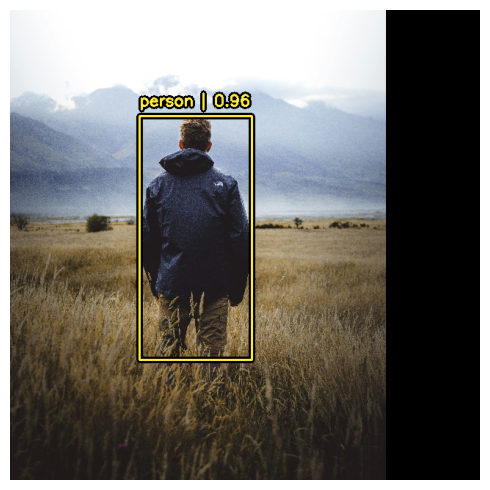

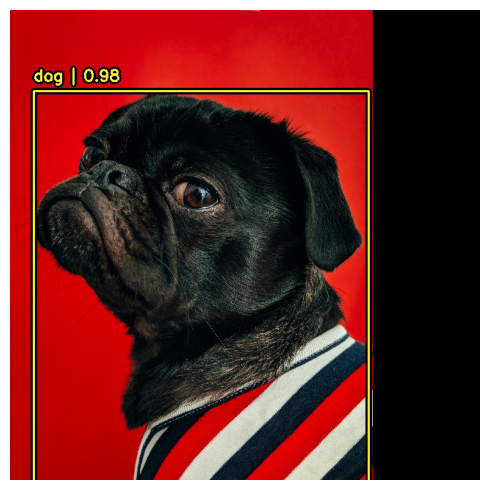

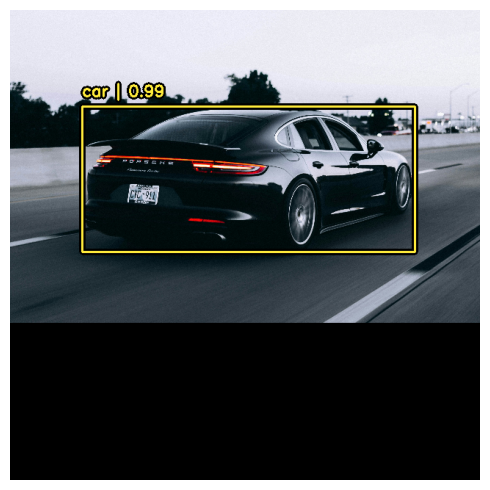

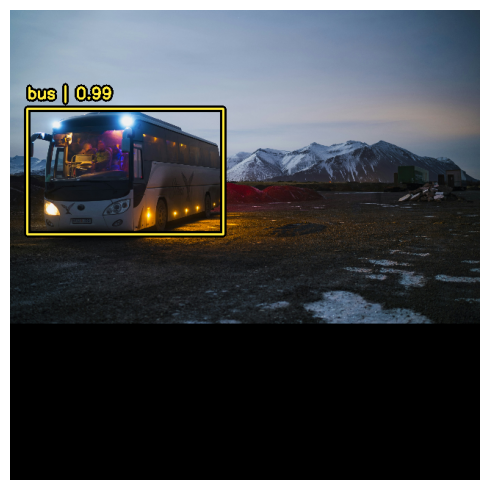

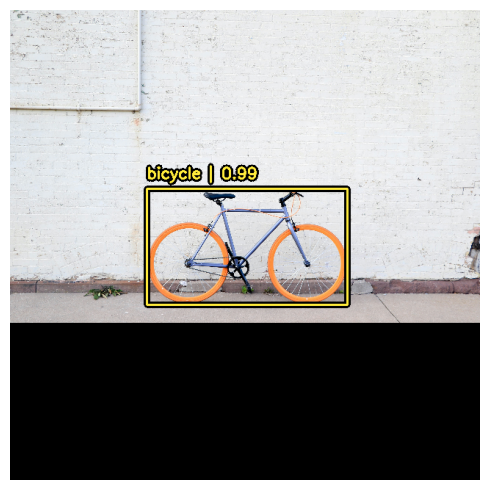

In [12]:
all_results = []

for idx, image in enumerate(images):
    print("=" * 60)
    print(f"Image {idx + 1}")

    resized_image, predictions = predict_image(model, image)
    detections = summarize_predictions(predictions, confidence_threshold=0.3)

    print("Detected objects:")
    for det in detections:
        print(f"- {det['label']} | confidence = {det['confidence']:.3f}")

    visualize_predictions(resized_image, predictions)

    all_results.append({
        "image_index": idx + 1,
        "detections": detections
    })

In [13]:
for item in all_results:
    print(f"\nImage {item['image_index']} summary:")
    if len(item["detections"]) == 0:
        print("No objects detected above threshold.")
    else:
        for det in item["detections"]:
            print(f"  {det['label']:12s}  score={det['confidence']:.3f}")


Image 1 summary:
  person        score=0.964

Image 2 summary:
  dog           score=0.984

Image 3 summary:
  car           score=0.988

Image 4 summary:
  bus           score=0.990

Image 5 summary:
  bicycle       score=0.989


### This exercise demonstrates object detection using a pre-trained YOLOV8 model from KerasCV trained on the Pascal VOC dataset. Five images were loaded and resized to 640×640 using pad_to_aspect_ratio=True to match the model’s input size while preserving the aspect ratio. The YOLOV8 detector was then used to perform inference and generate bounding boxes, class labels, and confidence scores for detected objects. The predictions were visualized by drawing bounding boxes and labels on the images. Finally, the results were analyzed by identifying correctly detected objects, recording their confidence scores, and noting any missed or incorrectly labeled objects.